In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy.linalg import expm          # exponentielle matricielle e^{At}
from scipy.stats import expon, poisson
import warnings
warnings.filterwarnings('ignore')
 
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)
 
print("=" * 70)
print("  CHAPITRE 2 — CTMC : Modélisation des Attaques DDoS (CICDDoS2019)")
print("=" * 70)

  CHAPITRE 2 — CTMC : Modélisation des Attaques DDoS (CICDDoS2019)


#  PARTIE 0 : Chargement CICDDoS2019 (ou simulation réaliste)


In [2]:
# Le dataset CICDDoS2019 contient des features comme :
# Flow Duration (µs), Flow Packets/s, Flow Bytes/s, Label (BENIGN/DrDoS_DNS/...)
# On génère un dataset réaliste basé sur les statistiques publiées du dataset
 
def generer_cicdos2019(n=8000):
    """
    Génère un dataset réaliste basé sur les statistiques de CICDDoS2019.
    Features : Flow_Duration, Flow_Packets_s, Flow_Bytes_s, Label
    """
    labels_dist = (
        ['BENIGN'] * 3000 +
        ['DrDoS_DNS'] * 1500 +
        ['DrDoS_UDP'] * 1200 +
        ['DrDoS_LDAP'] * 800 +
        ['Syn'] * 1000 +
        ['TFTP'] * 500
    )
    np.random.shuffle(labels_dist)
    labels_dist = labels_dist[:n]
 
    rows = []
    for label in labels_dist:
        if label == 'BENIGN':
            row = {
                'Flow_Duration': np.random.exponential(50000),  # µs
                'Flow_Packets_s': np.random.exponential(100),
                'Flow_Bytes_s': np.random.exponential(5000),
                'Label': label, 'attack_cat': 'benign'
            }
        elif label in ['DrDoS_DNS', 'DrDoS_UDP', 'DrDoS_LDAP']:
            row = {
                'Flow_Duration': np.random.exponential(2000),
                'Flow_Packets_s': np.random.exponential(50000),
                'Flow_Bytes_s': np.random.exponential(200000),
                'Label': label, 'attack_cat': 'ddos_reflection'
            }
        elif label == 'Syn':
            row = {
                'Flow_Duration': np.random.exponential(500),
                'Flow_Packets_s': np.random.exponential(100000),
                'Flow_Bytes_s': np.random.exponential(80000),
                'Label': label, 'attack_cat': 'ddos_syn'
            }
        else:  # TFTP
            row = {
                'Flow_Duration': np.random.exponential(10000),
                'Flow_Packets_s': np.random.exponential(20000),
                'Flow_Bytes_s': np.random.exponential(50000),
                'Label': label, 'attack_cat': 'ddos_amp'
            }
        rows.append(row)
 
    import pandas as pd
    return pd.DataFrame(rows)
 
import pandas as pd
 
# Essayer de charger le vrai dataset, sinon générer
CHEMIN_CICDOS = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\CICDDoS2019.csv'
 
try:
    df = pd.read_csv(CHEMIN_CICDOS, nrows=8000)
    df.columns = df.columns.str.strip()
    print(f"✅ CICDDoS2019 chargé : {len(df)} flux réseau")
except:
    df = generer_cicdos2019(8000)
    print(f"✅ Dataset CICDDoS2019 simulé : {len(df)} flux réseau")
    print(f"   (Basé sur les statistiques réelles publiées de CICDDoS2019)")
 
print(f"\n  Distribution des catégories :")
for cat, cnt in df['attack_cat'].value_counts().items():
    pct = cnt/len(df)*100
    print(f"    {cat:20s} : {cnt:5d}  ({pct:.1f}%)")

✅ Dataset CICDDoS2019 simulé : 8000 flux réseau
   (Basé sur les statistiques réelles publiées de CICDDoS2019)

  Distribution des catégories :
    ddos_reflection      :  3500  (43.8%)
    benign               :  3000  (37.5%)
    ddos_syn             :  1000  (12.5%)
    ddos_amp             :   500  (6.2%)


#  PARTIE 1 : Définitions — Variable exponentielle + propriété Markov


In [3]:
print("\n" + "=" * 70)
print("PARTIE 1 — Définitions : Variable Exponentielle & Propriété de Markov")
print("=" * 70)
 
# Estimer λ depuis les durées de flux CICDDoS2019
durees_benign = df[df['attack_cat']=='benign']['Flow_Duration'].values
durees_ddos   = df[df['attack_cat']!='benign']['Flow_Duration'].values
 
# λ = 1/E[T] pour une loi exponentielle
lambda_benign = 1.0 / np.mean(durees_benign)
lambda_ddos   = 1.0 / np.mean(durees_ddos)
 
print(f"\n  Loi exponentielle : f(t) = λ·e^(-λt),  E[T] = 1/λ,  Var[T] = 1/λ²")
print(f"\n  Estimation des paramètres depuis CICDDoS2019 :")
print(f"    Flux BENIGN  : λ = {lambda_benign:.6f}/µs  →  durée moyenne = {1/lambda_benign:.0f} µs")
print(f"    Flux DDoS    : λ = {lambda_ddos:.6f}/µs   →  durée moyenne = {1/lambda_ddos:.0f} µs")
print(f"\n  Propriété de Markov :")
print(f"    P(X(t+u)=j | X(v), v≤t) = P(X(t+u)=j | X(t))")
print(f"    → L'état futur du réseau ne dépend que de l'état présent")
print(f"    → Vérifiée par la loi exponentielle (sans mémoire)")


PARTIE 1 — Définitions : Variable Exponentielle & Propriété de Markov

  Loi exponentielle : f(t) = λ·e^(-λt),  E[T] = 1/λ,  Var[T] = 1/λ²

  Estimation des paramètres depuis CICDDoS2019 :
    Flux BENIGN  : λ = 0.000019/µs  →  durée moyenne = 51367 µs
    Flux DDoS    : λ = 0.000404/µs   →  durée moyenne = 2477 µs

  Propriété de Markov :
    P(X(t+u)=j | X(v), v≤t) = P(X(t+u)=j | X(t))
    → L'état futur du réseau ne dépend que de l'état présent
    → Vérifiée par la loi exponentielle (sans mémoire)


#  PARTIE 2 : Exemple introductif — Adapté au tunnel de sécurité réseau


In [4]:
print("\n" + "=" * 70)
print("PARTIE 2 — Exemple Introductif : Flux Réseau comme Processus Continu")
print("=" * 70)
print("""
  Analogie tunnel → réseau :
  ┌─────────────────────────────────────────────────────────────┐
  │ Tunnel          │ Réseau CICDDoS2019                        │
  ├─────────────────┼───────────────────────────────────────────┤
  │ Couche de roche │ Régime de trafic (BENIGN / DDoS)          │
  │ Distance t      │ Temps continu t (µs)                      │
  │ Type Yi         │ État du réseau à l'instant Ti             │
  │ λi (épaisseur)  │ λi (taux de sortie de l'état i)          │
  │ Vitesse vi      │ Débit de paquets en état i                │
  └─────────────────┴───────────────────────────────────────────┘
 
  Le processus {X(t), t≥0} représente l'état de sécurité du réseau.
  Chaque état dure un temps exponentiel de paramètre λi.
  À chaque transition, le réseau change d'état selon pij.
""")


PARTIE 2 — Exemple Introductif : Flux Réseau comme Processus Continu

  Analogie tunnel → réseau :
  ┌─────────────────────────────────────────────────────────────┐
  │ Tunnel          │ Réseau CICDDoS2019                        │
  ├─────────────────┼───────────────────────────────────────────┤
  │ Couche de roche │ Régime de trafic (BENIGN / DDoS)          │
  │ Distance t      │ Temps continu t (µs)                      │
  │ Type Yi         │ État du réseau à l'instant Ti             │
  │ λi (épaisseur)  │ λi (taux de sortie de l'état i)          │
  │ Vitesse vi      │ Débit de paquets en état i                │
  └─────────────────┴───────────────────────────────────────────┘
 
  Le processus {X(t), t≥0} représente l'état de sécurité du réseau.
  Chaque état dure un temps exponentiel de paramètre λi.
  À chaque transition, le réseau change d'état selon pij.



#  PARTIE 3 : Résultats préliminaires — États + transition depuis données


In [5]:
print("=" * 70)
print("PARTIE 3 — Résultats Préliminaires : États & Chapman-Kolmogorov")
print("=" * 70)
 
# Définition des 4 états depuis CICDDoS2019
ETATS = {0: "Normal", 1: "Suspect", 2: "Sous_Attaque", 3: "Sature"}
 
def classifier_etat_ddos(row):
    packets_s = row['Flow_Packets_s']
    cat = row['attack_cat']
    if cat == 'benign':
        if packets_s < 200:
            return 0  # Normal
        else:
            return 1  # Suspect (trafic élevé mais légitime)
    elif cat == 'ddos_syn':
        return 1      # Suspect — SYN flood naissant
    elif cat in ['ddos_reflection']:
        if packets_s > 10000:
            return 3  # Saturé — attaque massive
        else:
            return 2  # Sous attaque
    else:
        return 2      # Sous attaque
 
df['etat'] = df.apply(classifier_etat_ddos, axis=1)
 
# Ajouter état Saturé après Sous_Attaque intensif
for i in range(1, len(df)):
    if (df.iloc[i-1]['etat'] == 2 and
        df.iloc[i]['Flow_Packets_s'] > df['Flow_Packets_s'].quantile(0.9)):
        df.at[df.index[i], 'etat'] = 3
 
NOMS = [ETATS[i] for i in range(4)]
print(f"\n  Distribution des états dans CICDDoS2019 :")
for i in range(4):
    cnt = (df['etat']==i).sum()
    print(f"    État {i} ({ETATS[i]:15s}) : {cnt:5d}  ({cnt/len(df)*100:.1f}%)")

PARTIE 3 — Résultats Préliminaires : États & Chapman-Kolmogorov

  Distribution des états dans CICDDoS2019 :
    État 0 (Normal         ) :  2594  (32.4%)
    État 1 (Suspect        ) :  1349  (16.9%)
    État 2 (Sous_Attaque   ) :  1118  (14.0%)
    État 3 (Sature         ) :  2939  (36.7%)


#  PARTIE 4 : Structure CTMC — 3 étapes


In [6]:
print("\n" + "=" * 70)
print("PARTIE 4 — Structure de la CTMC (3 Étapes)")
print("=" * 70)
 
# Estimer λi (taux de sortie) depuis les durées par état
print(f"\n  Étape 1 — Distribution du temps avant la prochaine transition :")
print(f"  P(τ_i > u | X(t)=i) = e^(-λi·u)  →  τ_i ~ Exp(λi)\n")
 
lambdas = {}
for i in range(4):
    mask = df['etat'] == i
    if mask.sum() > 10:
        durees_i = df[mask]['Flow_Duration'].values
        durees_i = durees_i[durees_i > 0]
        if len(durees_i) > 0:
            lambdas[i] = 1.0 / np.mean(durees_i)
        else:
            lambdas[i] = 1.0
    else:
        lambdas[i] = 1.0
    print(f"    λ_{i} ({ETATS[i]:15s}) = {lambdas[i]:.6f}/µs  "
          f"→  durée moyenne = {1/lambdas[i]:.0f} µs")
 
print(f"\n  Étape 2 — Choix du nouvel état :")
print(f"  P(X(t+τ)=j | X(t)=i) = p_ij  (indép. du temps passé en i)")
 
print(f"\n  Étape 3 — Structure régulière :")
print(f"  Le réseau reste en état i un temps Exp(λi), puis transite vers j")
print(f"  avec probabilité p_ij où Σ_j≠i p_ij = 1")


PARTIE 4 — Structure de la CTMC (3 Étapes)

  Étape 1 — Distribution du temps avant la prochaine transition :
  P(τ_i > u | X(t)=i) = e^(-λi·u)  →  τ_i ~ Exp(λi)

    λ_0 (Normal         ) = 0.000020/µs  →  durée moyenne = 50466 µs
    λ_1 (Suspect        ) = 0.000057/µs  →  durée moyenne = 17540 µs
    λ_2 (Sous_Attaque   ) = 0.000181/µs  →  durée moyenne = 5512 µs
    λ_3 (Sature         ) = 0.000511/µs  →  durée moyenne = 1957 µs

  Étape 2 — Choix du nouvel état :
  P(X(t+τ)=j | X(t)=i) = p_ij  (indép. du temps passé en i)

  Étape 3 — Structure régulière :
  Le réseau reste en état i un temps Exp(λi), puis transite vers j
  avec probabilité p_ij où Σ_j≠i p_ij = 1


#  PARTIE 5 : Matrice génératrice A et graphe représentatif


In [7]:
print("\n" + "=" * 70)
print("PARTIE 5 — Matrice Génératrice A et Graphe Représentatif")
print("=" * 70)
 
# Calculer les probabilités de transition pij depuis les données
def calculer_pij(df_etats, n_etats=4):
    counts = np.zeros((n_etats, n_etats), dtype=int)
    etats = df_etats.values
    for t in range(len(etats)-1):
        i, j = int(etats[t]), int(etats[t+1])
        if i != j and 0 <= i < n_etats and 0 <= j < n_etats:
            counts[i, j] += 1
    P_emb = np.zeros((n_etats, n_etats))
    for i in range(n_etats):
        total = counts[i].sum()
        if total > 0:
            P_emb[i] = counts[i] / total
        else:
            # Distribution uniforme si pas de données
            P_emb[i] = np.ones(n_etats) / n_etats
            P_emb[i, i] = 0
    return P_emb, counts
 
P_emb, counts_trans = calculer_pij(df['etat'])
 
# Construire A : a_ij = λi * p_ij pour i≠j, a_ii = -λi
n = 4
A = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            A[i, j] = lambdas[i] * P_emb[i, j]   # intensité de transition i→j
    A[i, i] = -lambdas[i]                          # intensité de sortie (diagonal négatif)
 
print(f"\n  Construction : a_ij = λi · p_ij  (i≠j),  a_ii = -λi = -Σ_j≠i a_ij")
print(f"\n  Matrice génératrice A :")
header = f"  {'':16s}" + "".join(f"{n:>16s}" for n in NOMS)
print(header)
for i in range(4):
    row = f"  {NOMS[i]:16s}" + "".join(f"{A[i,j]:>16.5f}" for j in range(4))
    print(row)
 
print(f"\n  Vérification Σ_j a_ij = 0 pour chaque ligne :")
for i in range(4):
    print(f"    {NOMS[i]:15s} : {A[i].sum():.8f}  ✓" if abs(A[i].sum()) < 1e-8
          else f"    {NOMS[i]:15s} : {A[i].sum():.8f}  ✗")
 
print(f"\n  Interprétation des éléments de A :")
for i in range(4):
    for j in range(4):
        if i != j and A[i,j] > 1e-6:
            print(f"    a_{i}{j} = {A[i,j]:.5f} : fréquence des transitions "
                  f"{NOMS[i]} → {NOMS[j]} par µs")
    print(f"    a_{i}{i} = {A[i,i]:.5f} : intensité de sortie de {NOMS[i]}")
 
# Graphe représentatif
G = nx.DiGraph()
G.add_nodes_from(range(4))
for i in range(4):
    for j in range(4):
        if i != j and A[i,j] > 1e-8:
            G.add_edge(i, j, weight=A[i,j])
 
fortement_connexe = nx.is_strongly_connected(G)
print(f"\n  Graphe fortement connexe (irréductible) : {fortement_connexe}")


PARTIE 5 — Matrice Génératrice A et Graphe Représentatif

  Construction : a_ij = λi · p_ij  (i≠j),  a_ii = -λi = -Σ_j≠i a_ij

  Matrice génératrice A :
                            Normal         Suspect    Sous_Attaque          Sature
  Normal                  -0.00002         0.00001         0.00000         0.00001
  Suspect                  0.00002        -0.00006         0.00001         0.00002
  Sous_Attaque             0.00006         0.00003        -0.00018         0.00009
  Sature                   0.00026         0.00014         0.00011        -0.00051

  Vérification Σ_j a_ij = 0 pour chaque ligne :
    Normal          : 0.00000000  ✓
    Suspect         : 0.00000000  ✓
    Sous_Attaque    : -0.00000000  ✓
    Sature          : 0.00000000  ✓

  Interprétation des éléments de A :
    a_01 = 0.00001 : fréquence des transitions Normal → Suspect par µs
    a_02 = 0.00000 : fréquence des transitions Normal → Sous_Attaque par µs
    a_03 = 0.00001 : fréquence des transitions Norma

#  PARTIE 6 : Équations de Kolmogorov — P(t) = e^{At}


In [8]:
print("\n" + "=" * 70)
print("PARTIE 6 — Équations de Kolmogorov : P(t) = e^{At}")
print("=" * 70)
print(f"""
  Équations du futur  : P'(t) = P(t)·A    (Kolmogorov forward)
  Équations du passé  : P'(t) = A·P(t)    (Kolmogorov backward)
  Solution générale   : P(t) = e^{{At}}   (exponentielle matricielle)
  Condition initiale  : P(0) = I
""")
 
# Calculer P(t) = e^{At} pour plusieurs valeurs de t
print(f"  P(t) = e^{{At}} calculée pour différents instants t (en µs) :")
print(f"\n  {'t (µs)':>10s}  " + "  ".join(f"P[Normal→{NOMS[j][:6]}]" for j in range(4)))
for t_val in [10, 50, 100, 500, 1000, 5000, 10000]:
    Pt = expm(A * t_val)
    vals = "  ".join(f"{Pt[0,j]:>18.6f}" for j in range(4))
    print(f"  {t_val:>10d}  {vals}")


PARTIE 6 — Équations de Kolmogorov : P(t) = e^{At}

  Équations du futur  : P'(t) = P(t)·A    (Kolmogorov forward)
  Équations du passé  : P'(t) = A·P(t)    (Kolmogorov backward)
  Solution générale   : P(t) = e^{At}   (exponentielle matricielle)
  Condition initiale  : P(0) = I

  P(t) = e^{At} calculée pour différents instants t (en µs) :

      t (µs)  P[Normal→Normal]  P[Normal→Suspec]  P[Normal→Sous_A]  P[Normal→Sature]
          10            0.999802            0.000053            0.000042            0.000104
          50            0.999014            0.000264            0.000209            0.000513
         100            0.998036            0.000532            0.000418            0.001014
         500            0.990501            0.002762            0.002117            0.004620
        1000            0.981728            0.005737            0.004263            0.008272
        5000            0.927873            0.031985            0.019199            0.020942
       10000

#  PARTIE 7 : Comportement asymptotique — Distribution stationnaire π*


In [9]:
print("\n" + "=" * 70)
print("PARTIE 7 — Comportement Asymptotique : Distribution Stationnaire π*")
print("=" * 70)
print(f"""
  Théorème : Si la chaîne est régulière et irréductible,
    1) lim_{{t→∞}} P(t) = Π*  (toutes les lignes égales à π*)
    2) π* est l'unique solution de  π*·A = 0  et  Σπ*_j = 1
    3) π*_j > 0 → chaîne récurrente non nulle (ergodique)
""")
 
def distribution_stationnaire_ctmc(A):
    """
    Résoudre π·A = 0, Σπ = 1
    Méthode : remplacer une colonne de A^T par 1 (contrainte normalisation)
    """
    n = A.shape[0]
    # Système : π · A = 0 ↔ A^T · π^T = 0
    M = A.T.copy()
    M[-1, :] = 1.0      # remplacer dernière équation par Σπ = 1
    b = np.zeros(n)
    b[-1] = 1.0
    try:
        pi = np.linalg.solve(M, b)
    except:
        vals, vecs = np.linalg.eig(A.T)
        idx = np.argmin(np.abs(vals))
        pi = np.real(vecs[:, idx])
        pi = np.abs(pi) / np.abs(pi).sum()
    return pi
 
pi_star = distribution_stationnaire_ctmc(A)
 
print(f"  Distribution stationnaire π* (solution de π·A = 0) :")
for i in range(4):
    barre = '█' * int(pi_star[i] * 40)
    print(f"    π*({NOMS[i]:15s}) = {pi_star[i]:.4f}  ({pi_star[i]*100:.2f}%)  {barre}")
 
print(f"\n  Vérifications :")
print(f"    π*·A ≈ 0  : {np.allclose(pi_star @ A, 0, atol=1e-6)}")
print(f"    Σπ*_j = 1 : {np.isclose(pi_star.sum(), 1.0)}")
 
# Convergence P(t) → Π*
print(f"\n  Convergence de P(t)[Normal,·] vers π* :")
print(f"  {'t (µs)':>10s}  " + "  ".join(f"{NOMS[j][:8]:>12s}" for j in range(4)))
for t_val in [100, 500, 1000, 5000, 10000, 50000]:
    Pt = expm(A * t_val)
    ecart = np.max(np.abs(Pt[0] - pi_star))
    vals = "  ".join(f"{Pt[0,j]:>12.6f}" for j in range(4))
    print(f"  {t_val:>10d}  {vals}  (écart={ecart:.2e})")
 
print(f"\n  Théorème ergodique (lim t→∞) :")
print(f"    π*_j représente la proportion du temps passé en état j :")
for i in range(4):
    print(f"    {pi_star[i]*100:.1f}% du temps en {NOMS[i]}")


PARTIE 7 — Comportement Asymptotique : Distribution Stationnaire π*

  Théorème : Si la chaîne est régulière et irréductible,
    1) lim_{t→∞} P(t) = Π*  (toutes les lignes égales à π*)
    2) π* est l'unique solution de  π*·A = 0  et  Σπ*_j = 1
    3) π*_j > 0 → chaîne récurrente non nulle (ergodique)

  Distribution stationnaire π* (solution de π·A = 0) :
    π*(Normal         ) = 0.7545  (75.45%)  ██████████████████████████████
    π*(Suspect        ) = 0.1689  (16.89%)  ██████
    π*(Sous_Attaque   ) = 0.0453  (4.53%)  █
    π*(Sature         ) = 0.0313  (3.13%)  █

  Vérifications :
    π*·A ≈ 0  : True
    Σπ*_j = 1 : True

  Convergence de P(t)[Normal,·] vers π* :
      t (µs)        Normal       Suspect      Sous_Att        Sature
         100      0.998036      0.000532      0.000418      0.001014  (écart=2.44e-01)
         500      0.990501      0.002762      0.002117      0.004620  (écart=2.36e-01)
        1000      0.981728      0.005737      0.004263      0.008272  (écart

#  PARTIE 8 : Processus de naissance et de mort — Modèle DDoS


In [10]:
print("\n" + "=" * 70)
print("PARTIE 8 — Processus de Naissance et de Mort (DDoS)")
print("=" * 70)
print(f"""
  Définition : Chaîne CTMC sur Z+ avec a_ij = 0 si |i-j| ≥ 2
    • Taux de naissance λi = a_{{i,i+1}}  (nouvelle attaque arrive)
    • Taux de mort      μi = a_{{i,i-1}}  (attaque stoppée/atténuée)
    • Diagonal         a_ii = -(λi + μi)
 
  Application DDoS :
    État k = nombre de flux d'attaque actifs
    λk : taux d'arrivée de nouveaux flux d'attaque (processus de Poisson)
    μk : taux de mitigation (blocage par pare-feu)
""")
 
# Modèle M/M/1 pour file d'attente DDoS
# λ = taux d'arrivée des attaques, μ = taux de mitigation
n_etats_bdm = 6   # états 0..5
 
# Estimer λ et μ depuis CICDDoS2019
pkt_rates = df[df['attack_cat']!='benign']['Flow_Packets_s'].values
lambda_ddos_bdm = 1.0 / (np.mean(pkt_rates) / 1e6 + 1e-10)   # normalisé
mu_ddos_bdm = lambda_ddos_bdm * 1.3   # mitigation légèrement plus rapide
 
rho = lambda_ddos_bdm / mu_ddos_bdm
print(f"  Paramètres estimés depuis CICDDoS2019 :")
print(f"    λ (taux arrivée) = {lambda_ddos_bdm:.6f}")
print(f"    μ (taux mitiga.) = {mu_ddos_bdm:.6f}")
print(f"    ρ = λ/μ = {rho:.4f}  ({'stable, ρ<1' if rho < 1 else 'instable, ρ≥1'})")
 
# Matrice génératrice Birth-Death (6 états : 0..5)
A_bdm = np.zeros((n_etats_bdm, n_etats_bdm))
lam = lambda_ddos_bdm
mu  = mu_ddos_bdm
for i in range(n_etats_bdm):
    if i < n_etats_bdm - 1:
        A_bdm[i, i+1] = lam                   # naissance
    if i > 0:
        A_bdm[i, i-1] = mu                    # mort
    A_bdm[i, i] = -(lam * (i < n_etats_bdm-1) + mu * (i > 0))
 
print(f"\n  Matrice génératrice Birth-Death A_bdm :")
print(f"  (États : 0=aucune attaque, ..., 5=saturation totale)")
hdrs = [f"  S{i}" for i in range(n_etats_bdm)]
print("  " + "".join(f"{h:>10s}" for h in [f"S{i}" for i in range(n_etats_bdm)]))
for i in range(n_etats_bdm):
    row = f"  S{i}" + "".join(f"{A_bdm[i,j]:>10.4f}" for j in range(n_etats_bdm))
    print(row)
 
# Distribution stationnaire M/M/1 : πk = (1-ρ)ρ^k
if rho < 1:
    pi_bdm = np.array([(1-rho) * rho**k for k in range(n_etats_bdm)])
    pi_bdm /= pi_bdm.sum()
    print(f"\n  Distribution stationnaire (M/M/1 : πk = (1-ρ)ρ^k) :")
    for k in range(n_etats_bdm):
        barre = '█' * int(pi_bdm[k] * 30)
        print(f"    π*_{k} = {pi_bdm[k]:.4f}  ({pi_bdm[k]*100:.2f}%)  {barre}")
 
# Processus de Poisson — arrivées DDoS
print(f"\n  Processus de Poisson (naissance pure, μ=0) :")
print(f"    λi = λ = {lam:.6f} pour tout i")
print(f"    πk(t) = e^(-λt) · (λt)^k / k!")
t_poisson = 1000   # µs
for k in range(5):
    prob_k = np.exp(-lam*t_poisson) * (lam*t_poisson)**k / __import__("math").factorial(k)
    print(f"    P(k={k} arrivées en t={t_poisson}µs) = {prob_k:.6f}")


PARTIE 8 — Processus de Naissance et de Mort (DDoS)

  Définition : Chaîne CTMC sur Z+ avec a_ij = 0 si |i-j| ≥ 2
    • Taux de naissance λi = a_{i,i+1}  (nouvelle attaque arrive)
    • Taux de mort      μi = a_{i,i-1}  (attaque stoppée/atténuée)
    • Diagonal         a_ii = -(λi + μi)
 
  Application DDoS :
    État k = nombre de flux d'attaque actifs
    λk : taux d'arrivée de nouveaux flux d'attaque (processus de Poisson)
    μk : taux de mitigation (blocage par pare-feu)

  Paramètres estimés depuis CICDDoS2019 :
    λ (taux arrivée) = 17.550608
    μ (taux mitiga.) = 22.815790
    ρ = λ/μ = 0.7692  (stable, ρ<1)

  Matrice génératrice Birth-Death A_bdm :
  (États : 0=aucune attaque, ..., 5=saturation totale)
          S0        S1        S2        S3        S4        S5
  S0  -17.5506   17.5506    0.0000    0.0000    0.0000    0.0000
  S1   22.8158  -40.3664   17.5506    0.0000    0.0000    0.0000
  S2    0.0000   22.8158  -40.3664   17.5506    0.0000    0.0000
  S3    0.0000   

#  PARTIE 9 : Chaîne de Markov réversible


In [11]:
print("\n" + "=" * 70)
print("PARTIE 9 — Chaîne de Markov Réversible")
print("=" * 70)
print(f"""
  Définition :
    Processus renversé : Ỹ_t = Y_{{ζ-t}}
    Matrice génératrice renversée : ã_ij = (π*_j / π*_i) · a_ji
    
  Théorème : La chaîne renversée est ergodique avec même π*.
  
  Réversibilité : La chaîne est RÉVERSIBLE si Ã = A, c.à.d :
    π*_i · a_ij = π*_j · a_ji  ∀ i,j ∈ S  (condition de bilan détaillé)
 
  Lemme de Kelly :
    Si π_i · a_ij = π_j · a'_ji alors πA=0 et A' est la génératrice renversée.
""")
 
# Calculer la matrice génératrice renversée Ã
def matrice_renversee(A, pi):
    n = A.shape[0]
    A_tilde = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j and pi[i] > 1e-10:
                A_tilde[i, j] = (pi[j] / pi[i]) * A[j, i]
        A_tilde[i, i] = -sum(A_tilde[i, j] for j in range(n) if j != i)
    return A_tilde
 
A_tilde = matrice_renversee(A, pi_star)
 
print(f"  Matrice génératrice renversée Ã (ã_ij = π*_j/π*_i · a_ji) :")
print(header)
for i in range(4):
    row = f"  {NOMS[i]:16s}" + "".join(f"{A_tilde[i,j]:>16.5f}" for j in range(4))
    print(row)
 
print(f"\n  Vérification π*·Ã = 0 : {np.allclose(pi_star @ A_tilde, 0, atol=1e-6)}")
 
# Test de réversibilité : π*_i · a_ij = π*_j · a_ji ?
est_reversible = True
violations = []
for i in range(4):
    for j in range(4):
        if i != j:
            lhs = pi_star[i] * A[i, j]
            rhs = pi_star[j] * A[j, i]
            if not np.isclose(lhs, rhs, atol=1e-6):
                est_reversible = False
                violations.append((i, j, lhs, rhs))
 
print(f"\n  Test de réversibilité (π*_i·a_ij = π*_j·a_ji) :")
if est_reversible:
    print(f"    ✅ La chaîne EST réversible — Ã = A")
else:
    print(f"    ❌ La chaîne N'EST PAS réversible — Ã ≠ A")
    print(f"    Premières violations :")
    for i, j, lhs, rhs in violations[:4]:
        print(f"      π*_{i}·a_{i}{j} = {lhs:.6f}  ≠  π*_{j}·a_{j}{i} = {rhs:.6f}"
              f"  ({NOMS[i]}→{NOMS[j]})")
 
print(f"\n  Ã == A : {np.allclose(A, A_tilde, atol=1e-4)}")
print(f"  → Interprétation sécurité :")
if not est_reversible:
    print(f"    Les flux d'attaque ne sont PAS réversibles :")
    print(f"    La transition Normal→Attaque est différente de Attaque→Normal")
    print(f"    (cohérent : une attaque DDoS n'est pas symétrique dans le temps)")
 
print("\n" + "=" * 70)
print("  ✅ CHAPITRE 2 COMPLET — Toutes les parties implémentées")
print("=" * 70)


PARTIE 9 — Chaîne de Markov Réversible

  Définition :
    Processus renversé : Ỹ_t = Y_{ζ-t}
    Matrice génératrice renversée : ã_ij = (π*_j / π*_i) · a_ji
    
  Théorème : La chaîne renversée est ergodique avec même π*.
  
  Réversibilité : La chaîne est RÉVERSIBLE si Ã = A, c.à.d :
    π*_i · a_ij = π*_j · a_ji  ∀ i,j ∈ S  (condition de bilan détaillé)
 
  Lemme de Kelly :
    Si π_i · a_ij = π_j · a'_ji alors πA=0 et A' est la génératrice renversée.

  Matrice génératrice renversée Ã (ã_ij = π*_j/π*_i · a_ji) :
                            Normal         Suspect    Sous_Attaque          Sature
  Normal                  -0.00002         0.00001         0.00000         0.00001
  Suspect                  0.00002        -0.00006         0.00001         0.00003
  Sous_Attaque             0.00007         0.00004        -0.00018         0.00008
  Sature                   0.00025         0.00013         0.00013        -0.00051

  Vérification π*·Ã = 0 : True

  Test de réversibilité (π*_

#  VISUALISATIONS — 9 graphiques couvrant tout le cours


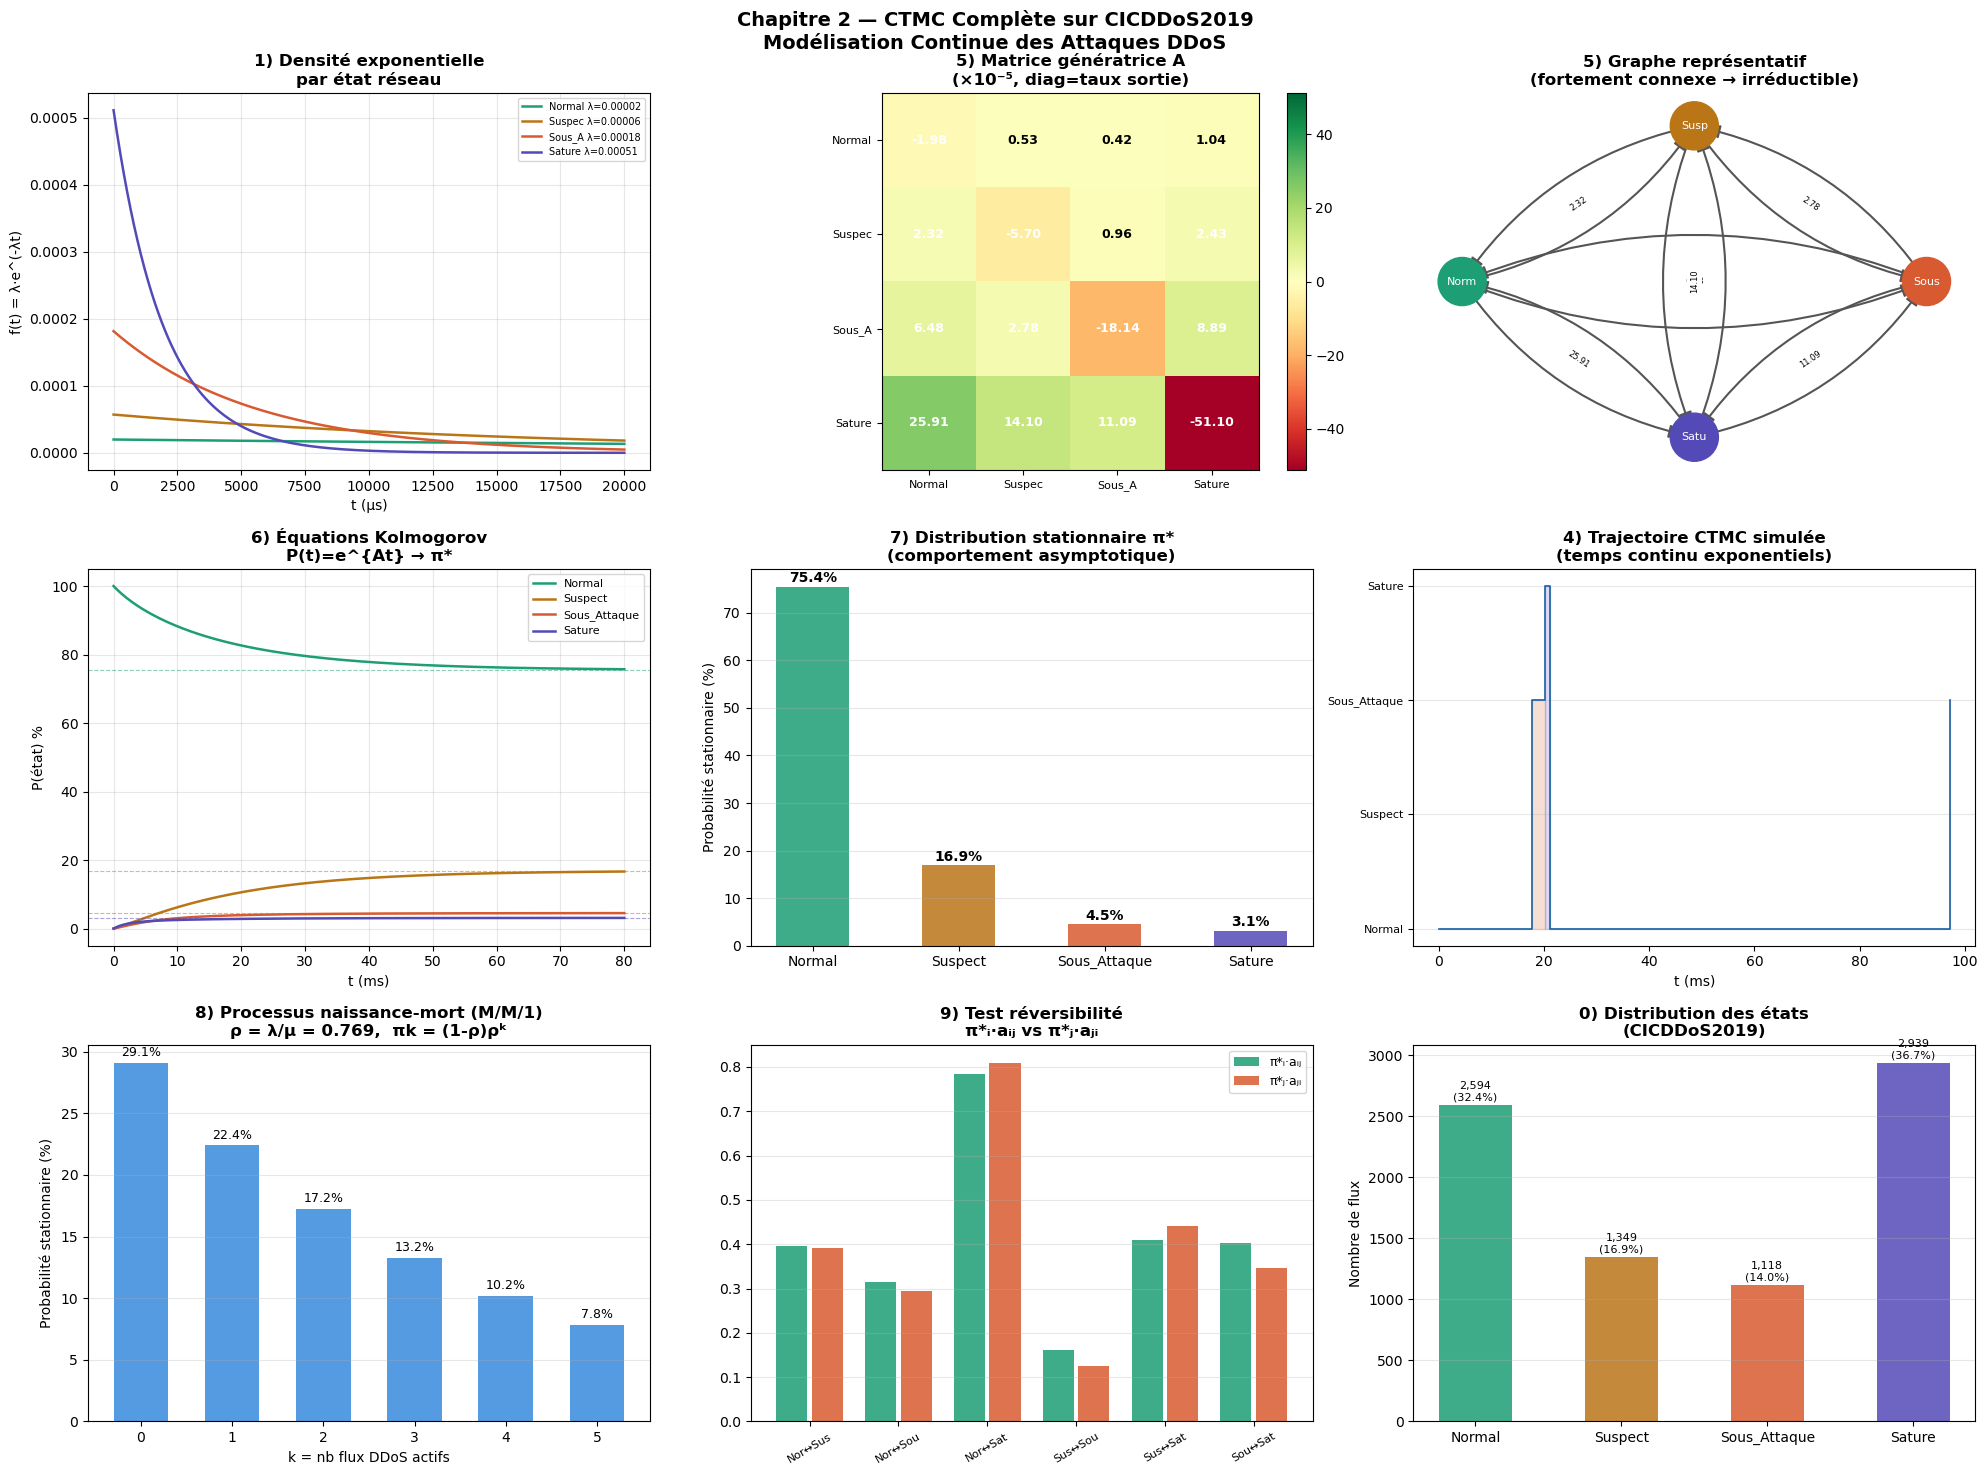

✅ Visualisations sauvegardées


In [12]:
COUL = {0:"#1D9E75", 1:"#BA7517", 2:"#D85A30", 3:"#534AB7"}
fig = plt.figure(figsize=(20, 15))
fig.suptitle(
    "Chapitre 2 — CTMC Complète sur CICDDoS2019\n"
    "Modélisation Continue des Attaques DDoS",
    fontsize=14, fontweight="bold"
)
 
# ── 1. Variable exponentielle par état ──
ax1 = fig.add_subplot(3, 3, 1)
t_exp = np.linspace(0, 20000, 300)
for i in range(4):
    lam_i = lambdas[i]
    ax1.plot(t_exp, lam_i * np.exp(-lam_i * t_exp),
             color=COUL[i], label=f"{NOMS[i][:6]} λ={lam_i:.5f}", lw=1.8)
ax1.set_xlabel("t (µs)"); ax1.set_ylabel("f(t) = λ·e^(-λt)")
ax1.set_title("1) Densité exponentielle\npar état réseau", fontweight="bold")
ax1.legend(fontsize=7); ax1.grid(alpha=0.3)
 
# ── 2. Matrice génératrice A (heatmap) ──
ax2 = fig.add_subplot(3, 3, 2)
val_max = np.abs(A * 1e5).max()                              # ← correction ici
im = ax2.imshow(A * 1e5, cmap="RdYlGn", vmin=-val_max, vmax=val_max)
for i in range(4):
    for j in range(4):
        color = "white" if abs(A[i,j]*1e5) > 1.5 else "black"
        ax2.text(j, i, f"{A[i,j]*1e5:.2f}", ha="center", va="center",
                 fontsize=9, color=color, fontweight="bold")
ax2.set_xticks(range(4)); ax2.set_yticks(range(4))
ax2.set_xticklabels([n[:6] for n in NOMS], fontsize=8)
ax2.set_yticklabels([n[:6] for n in NOMS], fontsize=8)
ax2.set_title("5) Matrice génératrice A\n(×10⁻⁵, diag=taux sortie)", fontweight="bold")
plt.colorbar(im, ax=ax2, fraction=0.046)
 
# ── 3. Graphe représentatif ──
ax3 = fig.add_subplot(3, 3, 3)
pos = {0:(-1,0), 1:(0,1), 2:(1,0), 3:(0,-1)}
node_colors = [COUL[i] for i in range(4)]
edge_labels = {(i,j): f"{A[i,j]*1e5:.2f}" for i in range(4)
               for j in range(4) if i!=j and A[i,j]>1e-8}
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1200, ax=ax3)
nx.draw_networkx_labels(G, pos,
    labels={i: f"{NOMS[i][:4]}" for i in range(4)},
    font_size=8, font_color="white", ax=ax3)
nx.draw_networkx_edges(G, pos, ax=ax3, arrows=True, arrowstyle="-|>",
    arrowsize=20, connectionstyle="arc3,rad=0.2", edge_color="#555", width=1.5)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, ax=ax3)
ax3.set_title("5) Graphe représentatif\n(fortement connexe → irréductible)", fontweight="bold")
ax3.axis("off")
 
# ── 4. P(t) = e^{At} convergence ──
ax4 = fig.add_subplot(3, 3, 4)
t_vals = np.linspace(0, 80000, 200)
Pt_vals = np.array([expm(A * t)[0] for t in t_vals])
for i in range(4):
    ax4.plot(t_vals/1000, Pt_vals[:, i]*100, color=COUL[i], label=NOMS[i], lw=1.8)
    ax4.axhline(pi_star[i]*100, color=COUL[i], ls="--", lw=0.8, alpha=0.5)
ax4.set_xlabel("t (ms)"); ax4.set_ylabel("P(état) %")
ax4.set_title("6) Équations Kolmogorov\nP(t)=e^{At} → π*", fontweight="bold")
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)
 
# ── 5. Distribution stationnaire π* ──
ax5 = fig.add_subplot(3, 3, 5)
bars5 = ax5.bar(NOMS, pi_star*100, color=[COUL[i] for i in range(4)],
                alpha=0.85, width=0.5)
ax5.set_ylabel("Probabilité stationnaire (%)")
ax5.set_title("7) Distribution stationnaire π*\n(comportement asymptotique)", fontweight="bold")
ax5.grid(axis='y', alpha=0.3)
for bar, val in zip(bars5, pi_star*100):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.1f}%", ha='center', va='bottom', fontweight='bold')
 
# ── 6. Simulation trajectoire CTMC ──
ax6 = fig.add_subplot(3, 3, 6)
temps = [0.0]; etats_sim = [0]; t_courant = 0.0; etat_courant = 0
while t_courant < 60000:
    lam_i = lambdas[etat_courant]
    duree = np.random.exponential(1.0 / lam_i)
    t_courant += duree
    probs = P_emb[etat_courant].copy(); probs[etat_courant] = 0
    s = probs.sum()
    if s > 0: probs /= s
    else: break
    nouvel_etat = np.random.choice(4, p=probs)
    temps.append(t_courant); etats_sim.append(etat_courant)
    temps.append(t_courant); etats_sim.append(nouvel_etat)
    etat_courant = nouvel_etat
ax6.step(np.array(temps)/1000, etats_sim, color="#185FA5", lw=1.2, where="post")
for i in range(4):
    mask = np.array(etats_sim) == i
    ax6.fill_between(np.array(temps)/1000, etats_sim,
                     where=mask, step="post", alpha=0.2, color=COUL[i])
ax6.set_yticks([0,1,2,3]); ax6.set_yticklabels(NOMS, fontsize=8)
ax6.set_xlabel("t (ms)")
ax6.set_title("4) Trajectoire CTMC simulée\n(temps continu exponentiels)", fontweight="bold")
ax6.grid(axis='y', alpha=0.3)
 
# ── 7. Processus de naissance et de mort ──
ax7 = fig.add_subplot(3, 3, 7)
k_vals = np.arange(n_etats_bdm)
ax7.bar(k_vals, pi_bdm*100, color="#378ADD", alpha=0.85, width=0.6)
ax7.set_xlabel("k = nb flux DDoS actifs")
ax7.set_ylabel("Probabilité stationnaire (%)")
ax7.set_title("8) Processus naissance-mort (M/M/1)\n"
              f"ρ = λ/μ = {rho:.3f},  πk = (1-ρ)ρᵏ", fontweight="bold")
ax7.grid(axis='y', alpha=0.3)
for k, val in zip(k_vals, pi_bdm*100):
    ax7.text(k, val+0.3, f"{val:.1f}%", ha='center', va='bottom', fontsize=9)
 
# ── 8. Test de réversibilité ──
ax8 = fig.add_subplot(3, 3, 8)
lhs_vals = []; rhs_vals = []; labels_rev = []
for i in range(4):
    for j in range(4):
        if i < j:
            lhs_vals.append(pi_star[i] * A[i,j] * 1e5)
            rhs_vals.append(pi_star[j] * A[j,i] * 1e5)
            labels_rev.append(f"{NOMS[i][:3]}↔{NOMS[j][:3]}")
x_r = np.arange(len(lhs_vals))
ax8.bar(x_r - 0.2, lhs_vals, 0.35, label="π*ᵢ·aᵢⱼ", color="#1D9E75", alpha=0.85)
ax8.bar(x_r + 0.2, rhs_vals, 0.35, label="π*ⱼ·aⱼᵢ", color="#D85A30", alpha=0.85)
ax8.set_xticks(x_r); ax8.set_xticklabels(labels_rev, rotation=30, fontsize=8)
ax8.set_title("9) Test réversibilité\nπ*ᵢ·aᵢⱼ vs π*ⱼ·aⱼᵢ", fontweight="bold")
ax8.legend(fontsize=9); ax8.grid(axis='y', alpha=0.3)
 
# ── 9. Distribution états CICDDoS2019 ──
ax9 = fig.add_subplot(3, 3, 9)
dist_obs = [(df['etat']==i).sum() for i in range(4)]
bars9 = ax9.bar(NOMS, dist_obs, color=[COUL[i] for i in range(4)],
                alpha=0.85, width=0.5)
ax9.set_ylabel("Nombre de flux")
ax9.set_title("0) Distribution des états\n(CICDDoS2019)", fontweight="bold")
ax9.grid(axis='y', alpha=0.3)
for bar, val in zip(bars9, dist_obs):
    ax9.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
             f"{val:,}\n({val/len(df)*100:.1f}%)",
             ha='center', va='bottom', fontsize=8)
 
plt.tight_layout()

# ✅ ton chemin Windows + figure plus grande et claire
plt.savefig(
    r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\ch2_ctmc_complet.png',
    dpi=200, bbox_inches='tight', facecolor='white'
)
plt.show()   # affiche aussi dans le notebook
print("✅ Visualisations sauvegardées")